<a href="https://colab.research.google.com/github/BilalAhmed563/Brain_tumor_classification/blob/main/Brain_Tumor_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install kaggle API to download the dataset
!pip install kaggle -q

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [2]:
import os
import json

# ---- Paste your Kaggle credentials here ----
KAGGLE_USERNAME = "dl1028"   # e.g. "bilal123"
KAGGLE_KEY      = "KGAT_2af293952695f10effb1dcd99b17dab0"      # the long token string from Kaggle

# Create kaggle.json manually
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("kaggle.json created successfully!")

kaggle.json created successfully!


## Step 2: Upload Kaggle API Key & Download Dataset

In [3]:
# Download Brain Tumor MRI Dataset from Kaggle
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

# Unzip the dataset
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_data

# Check folder structure
!ls brain_tumor_data/
!ls brain_tumor_data/Training/
print("\nDataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:09<00:00, 16.7MB/s]

Testing  Training
glioma	meningioma  notumor  pituitary

Dataset downloaded and extracted!


## Step 3: Import Libraries & Set Configuration

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report

# ---- Configuration ----
DATA_DIR   = '/content/brain_tumor_data'   # root folder of unzipped dataset
TRAIN_DIR  = os.path.join(DATA_DIR, 'Training')
TEST_DIR   = os.path.join(DATA_DIR, 'Testing')

IMG_SIZE   = 224          # ResNet50 expects 224x224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR_HEAD    = 1e-3         # learning rate for the new classifier head
LR_FEAT    = 1e-4         # learning rate for pretrained ResNet features
NUM_CLASSES = 4
SEED       = 42

# Class names (alphabetical order — matches ImageFolder default)
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## Step 4: Data Preprocessing & Augmentation

In [5]:
# ImageNet normalization values (required for pretrained ResNet50)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms: augmentation + normalize
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation / Test transforms: only resize + normalize (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Load training dataset
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)

# Split training into train (85%) and validation (15%)
val_size   = int(0.15 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply correct (no-augmentation) transform to validation split
val_dataset.dataset = datasets.ImageFolder(TRAIN_DIR, transform=val_test_transforms)

# Test dataset
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples   : {train_size}")
print(f"Validation samples : {val_size}")
print(f"Test samples       : {len(test_dataset)}")
print(f"Classes            : {full_train_dataset.classes}")

Training samples   : 4760
Validation samples : 840
Test samples       : 1600
Classes            : ['glioma', 'meningioma', 'notumor', 'pituitary']


## Step 5: Visualize Sample Images

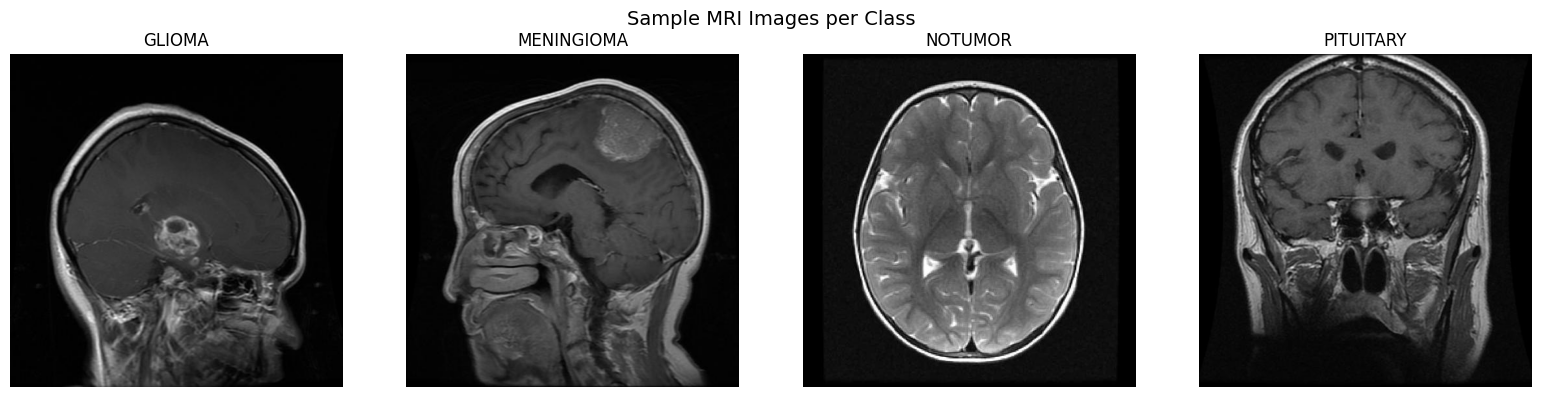

Sample images saved as sample_images.png


In [6]:
# Show one sample image from each class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Sample MRI Images per Class', fontsize=14)

# Denormalize for display
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

for idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    img_file  = os.listdir(class_dir)[0]
    img_path  = os.path.join(class_dir, img_file)
    img       = Image.open(img_path).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(class_name.upper())
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sample images saved as sample_images.png")

## Step 6: Build the ResNet50 Model

In [7]:
# Load ResNet50 with pretrained ImageNet weights
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Replace the final fully connected layer
# Original: fc = Linear(2048, 1000)  ->  New: fc = Linear(2048, 4)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

# Move model to GPU
model = model.to(device)

# --- Differential Learning Rates ---
# The pretrained backbone (conv layers) gets a low LR to preserve learned features
# The new head (fc) gets a higher LR to learn quickly from scratch
optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR_FEAT},
    {'params': model.fc.parameters(), 'lr': LR_HEAD}
])

# Step LR: halve the LR every 5 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Loss function
criterion = nn.CrossEntropyLoss()

# Print model summary
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model architecture  : ResNet50 + Custom Dropout Head")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


Total parameters    : 23,516,228
Trainable parameters: 23,516,228
Model architecture  : ResNet50 + Custom Dropout Head


## Step 7: Training Loop

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one epoch of training. Returns avg loss and accuracy."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds      = outputs.max(1)
        correct      += preds.eq(labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on val/test set. Returns avg loss and accuracy."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds      = outputs.max(1)
            correct      += preds.eq(labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total


# ---- Training ----
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_model_wt = None

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Time':>6}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc*100:>8.2f}% | {val_loss:>8.4f} | {val_acc*100:>6.2f}% | {elapsed:>5.1f}s")

    # Save best model weights
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_model_wt = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"         ** New best val accuracy: {best_val_acc*100:.2f}% — model saved **")

print(f"\nTraining complete. Best validation accuracy: {best_val_acc*100:.2f}%")

# Restore best weights
model.load_state_dict(best_model_wt)
torch.save(model.state_dict(), 'brain_tumor_resnet50_best.pth')
print("Best model saved to brain_tumor_resnet50_best.pth")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |   Time
-----------------------------------------------------------------
    1 |     0.3140 |    88.66% |   0.2179 |  92.38% |  54.9s
         ** New best val accuracy: 92.38% — model saved **
    2 |     0.1244 |    96.03% |   0.1907 |  93.81% |  57.6s
         ** New best val accuracy: 93.81% — model saved **
    3 |     0.0769 |    97.50% |   0.1406 |  96.31% |  61.9s
         ** New best val accuracy: 96.31% — model saved **
    4 |     0.0637 |    97.63% |   0.0801 |  97.38% |  58.6s
         ** New best val accuracy: 97.38% — model saved **
    5 |     0.0588 |    98.00% |   0.0456 |  98.45% |  57.3s
         ** New best val accuracy: 98.45% — model saved **
    6 |     0.0258 |    99.20% |   0.0269 |  98.93% |  58.0s
         ** New best val accuracy: 98.93% — model saved **
    7 |     0.0108 |    99.62% |   0.0338 |  98.93% |  57.4s
    8 |     0.0112 |    99.73% |   0.0298 |  99.29% |  57.4s
         ** New best val accura

## Step 8: Plot Training Curves

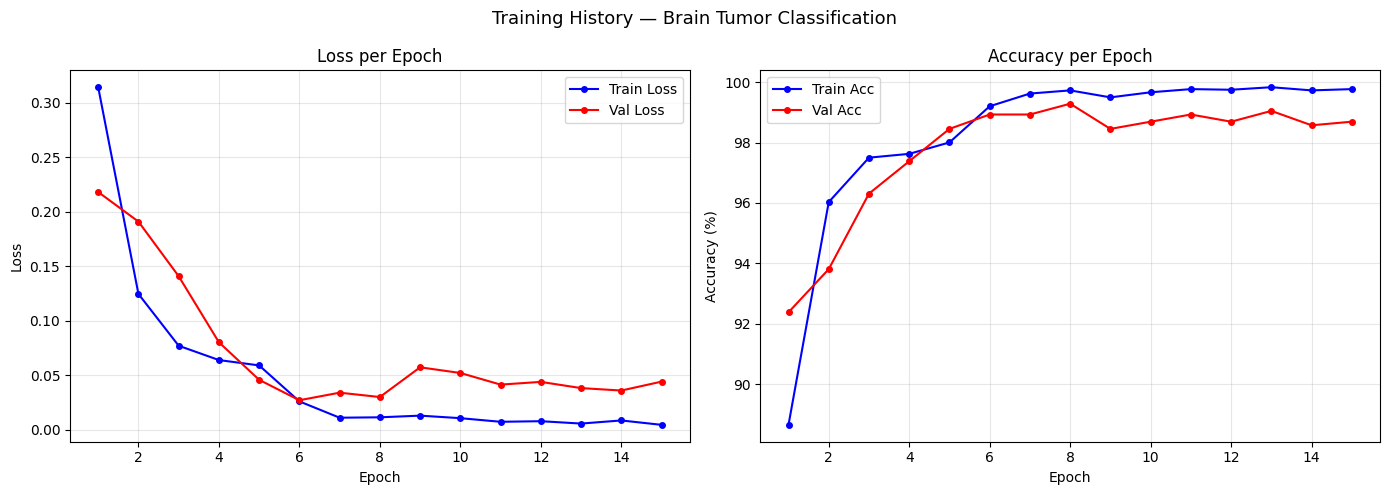

Training curves saved as training_curves.png


In [9]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Brain Tumor Classification', fontsize=13)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Training curves saved as training_curves.png")

## Step 9: Evaluate on Test Set

In [10]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

Test Loss     : 0.3624
Test Accuracy : 95.75%


## Step 10: Confusion Matrix & Classification Report

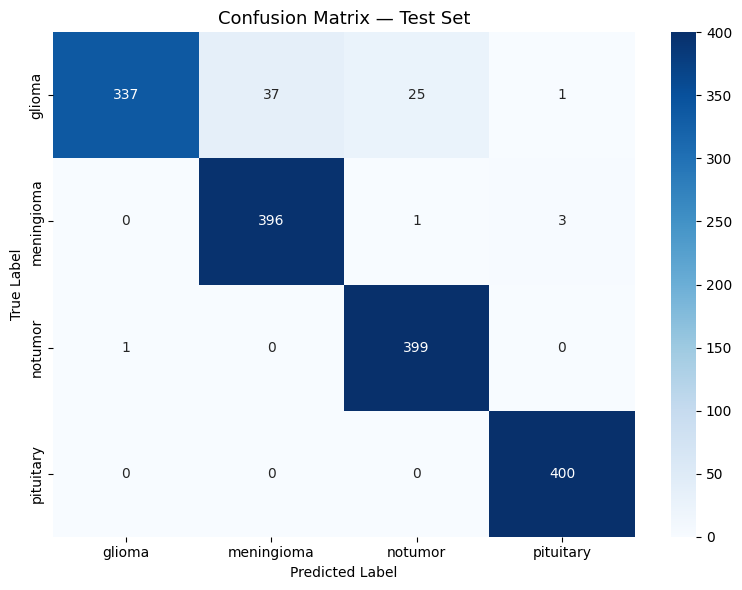


Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.84      0.91       400
  meningioma       0.91      0.99      0.95       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



In [11]:
# Collect all predictions and true labels from test set
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## Step 11: Visualize Predictions on Test Images

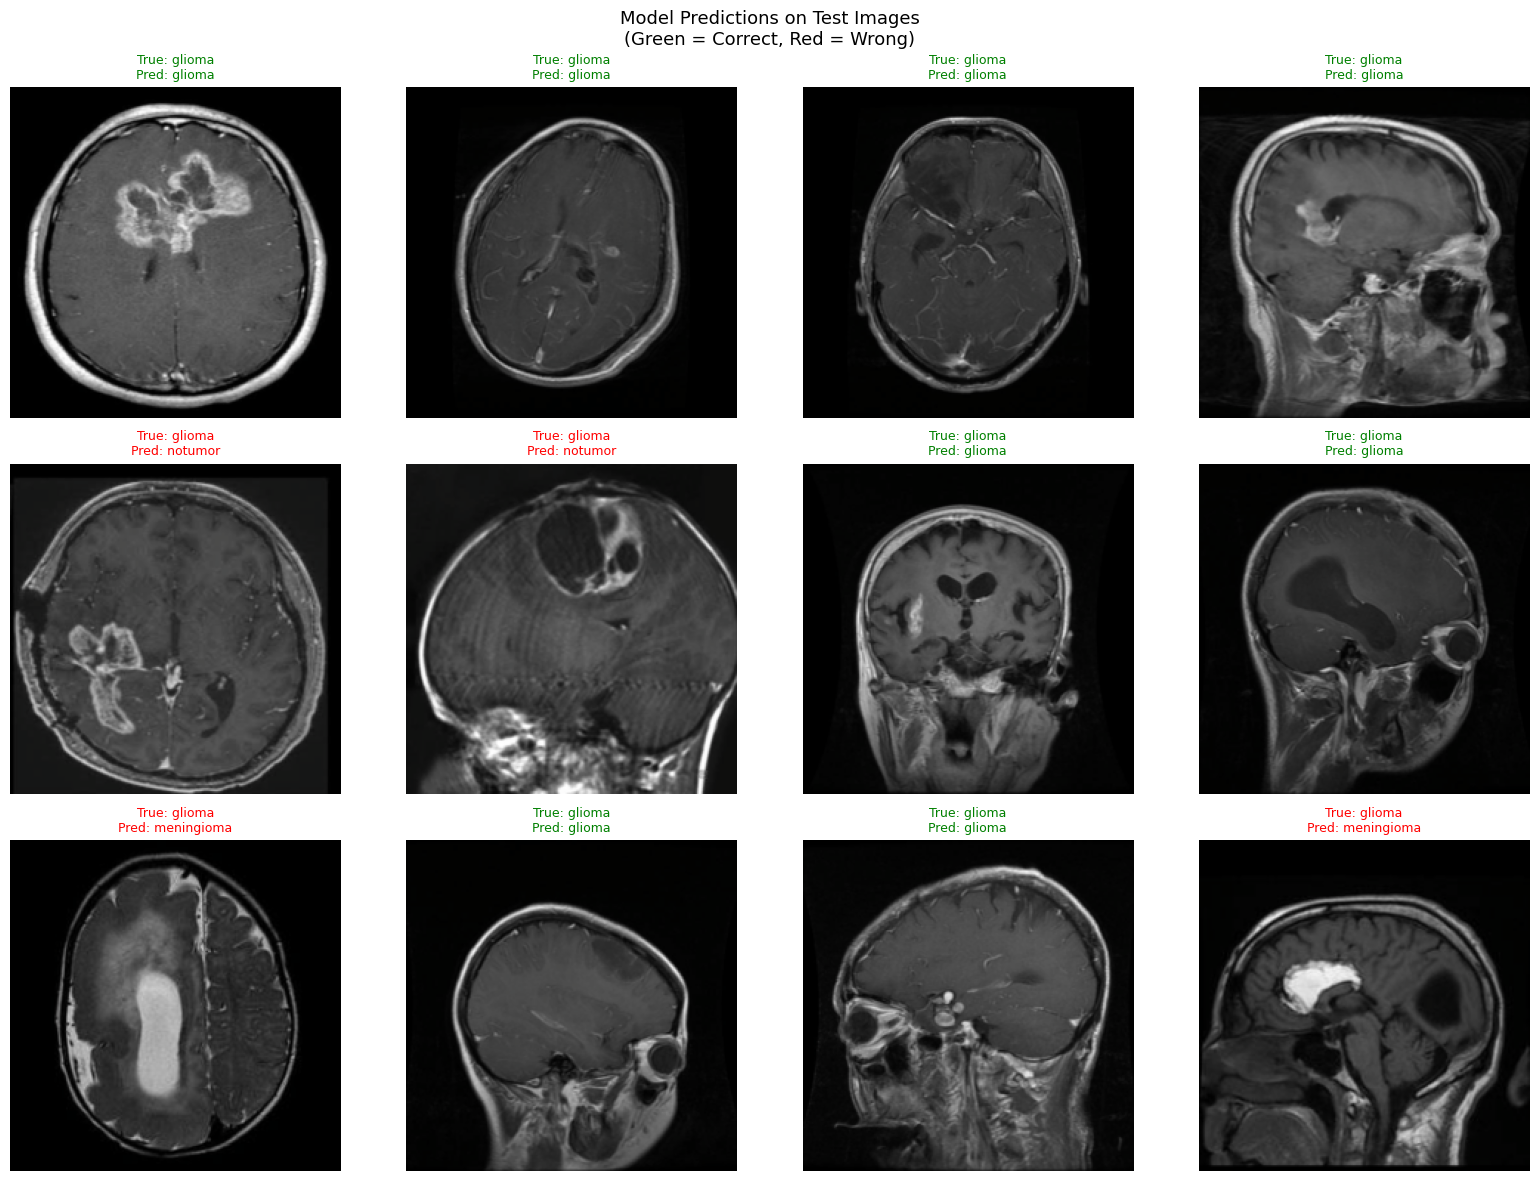

Predictions saved as predictions.png


In [12]:
# Show 12 random test images with predicted vs true labels
# Green title = correct prediction, Red title = wrong prediction

inv_normalize = transforms.Compose([
    transforms.Normalize(
        mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1/s for s in IMAGENET_STD]
    )
])

model.eval()
images_shown, preds_shown, labels_shown = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs    = model(images_gpu)
        _, preds   = outputs.max(1)
        for i in range(len(images)):
            images_shown.append(images[i])
            preds_shown.append(preds[i].item())
            labels_shown.append(labels[i].item())
        if len(images_shown) >= 12:
            break

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Model Predictions on Test Images\n(Green = Correct, Red = Wrong)', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    img = inv_normalize(images_shown[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img, cmap='gray' if img.shape[2] == 1 else None)
    true_label = CLASS_NAMES[labels_shown[i]]
    pred_label = CLASS_NAMES[preds_shown[i]]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Predictions saved as predictions.png")

## Step 12: Final Summary

In [13]:
print("=" * 55)
print("      BRAIN TUMOR CLASSIFICATION — FINAL SUMMARY")
print("=" * 55)
print(f"  Model          : ResNet50 (ImageNet pretrained)")
print(f"  Dataset        : Brain MRI Images (Kaggle)")
print(f"  Classes        : {CLASS_NAMES}")
print(f"  Train Samples  : {train_size}")
print(f"  Val Samples    : {val_size}")
print(f"  Test Samples   : {len(test_dataset)}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {NUM_EPOCHS}")
print(f"  Optimizer      : Adam (differential LR)")
print(f"  Scheduler      : StepLR (step=5, gamma=0.5)")
print("-" * 55)
print(f"  Best Val Acc   : {best_val_acc*100:.2f}%")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test Loss      : {test_loss:.4f}")
print("=" * 55)
print("  Files saved:")
print("    brain_tumor_resnet50_best.pth  <- model weights")
print("    training_curves.png            <- loss & accuracy plots")
print("    confusion_matrix.png           <- confusion matrix")
print("    predictions.png                <- sample predictions")
print("    sample_images.png              <- one sample per class")
print("=" * 55)

      BRAIN TUMOR CLASSIFICATION — FINAL SUMMARY
  Model          : ResNet50 (ImageNet pretrained)
  Dataset        : Brain MRI Images (Kaggle)
  Classes        : ['glioma', 'meningioma', 'notumor', 'pituitary']
  Train Samples  : 4760
  Val Samples    : 840
  Test Samples   : 1600
  Batch Size     : 32
  Epochs         : 15
  Optimizer      : Adam (differential LR)
  Scheduler      : StepLR (step=5, gamma=0.5)
-------------------------------------------------------
  Best Val Acc   : 99.29%
  Test Accuracy  : 95.75%
  Test Loss      : 0.3624
  Files saved:
    brain_tumor_resnet50_best.pth  <- model weights
    training_curves.png            <- loss & accuracy plots
    confusion_matrix.png           <- confusion matrix
    predictions.png                <- sample predictions
    sample_images.png              <- one sample per class
